KeyboardInterrupt: 

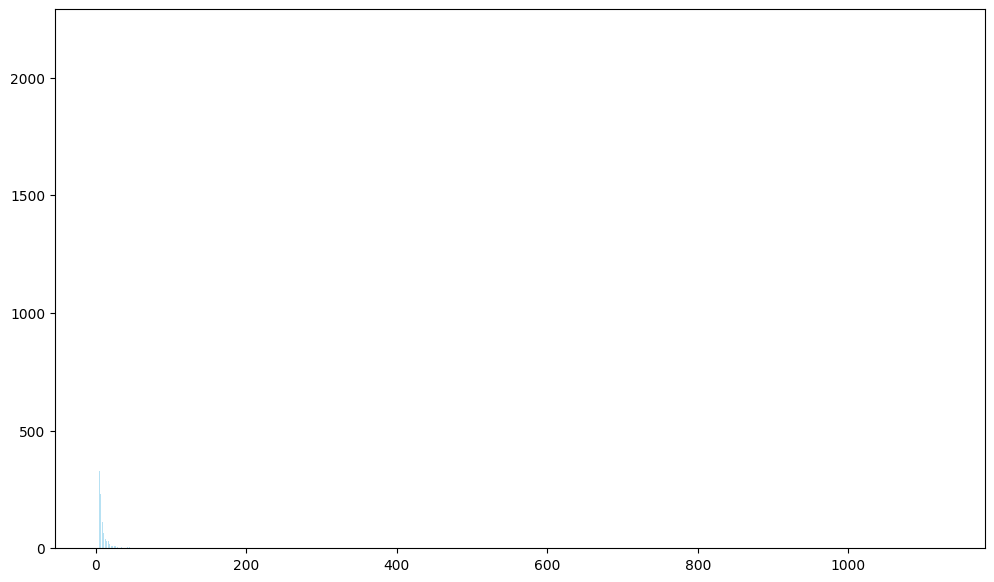

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# List of (CSV path, label for legend)
csv_files = [
    ('/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/th50.csv', 'Threshold 10'),
    ('/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/th60.csv', 'Threshold 20'),
    ('/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/th70.csv', 'Threshold 30'),
    ('/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/th80.csv', 'Threshold 40'),
    ('/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/th90.csv', 'Threshold 50'),
]

# Define colors for each threshold
colors = ['skyblue', 'orange', 'green', 'red', 'purple']

plt.figure(figsize=(12, 7))

for (csv_path, label), color in zip(csv_files, colors):
    try:
        df = pd.read_csv(csv_path)

        # Ensure numeric labels
        df['Cluster_Label'] = pd.to_numeric(df['Cluster_Label'], errors='coerce')

        # Get cluster labels and count sizes
        labels = df['Cluster_Label'].dropna().astype(int).tolist()
        cluster_sizes = {label: labels.count(label) for label in set(labels) if label >= 0}
        filtered_sizes = [size for size in cluster_sizes.values() if size >= 2]

        if not filtered_sizes:
            print(f"No valid clusters in {label}")
            continue

        # Plot histogram for this threshold
        plt.hist(filtered_sizes, bins=range(2, max(filtered_sizes) + 2),
                 align='left', rwidth=0.5, alpha=0.6, color=color, label=label)

    except Exception as e:
        print(f"Error processing {csv_path}: {e}")

plt.yscale('log')
plt.xlabel("Cluster Size")
plt.ylabel("Frequency (log scale)")
plt.title("Cluster Size Distribution Across Thresholds (Size ≥ 2)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter, defaultdict

# Font and style settings
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.weight'] = 600
plt.rcParams['font.size'] = 16

AXIS_FONT = {'family': 'DejaVu Sans', 'weight': 600, 'size': 22}
TITLE_FONT = {'family': 'DejaVu Sans', 'weight': 600, 'size': 22}
TICK_FONT_SIZE = 22

# Paths to 5 CSVs
csv_paths = [
    '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th50.csv',
    '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th60.csv',
    '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th70.csv',
    '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th80.csv',
    '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th90.csv',
]

# Accumulate frequencies
total_cluster_counts = defaultdict(int)

for csv_path in csv_paths:
    try:
        df = pd.read_csv(csv_path)
        df['Cluster_Label'] = pd.to_numeric(df['Cluster_Label'], errors='coerce')
        labels = df['Cluster_Label'].dropna().astype(int).tolist()
        cluster_sizes = Counter([label for label in labels if label >= 0])
        size_distribution = Counter(cluster_sizes.values())

        for size, count in size_distribution.items():
            if size >= 2:
                total_cluster_counts[size] += count
    except Exception as e:
        print(f"Error processing {csv_path}: {e}")

# Average the counts
num_files = len(csv_paths)
average_cluster_counts = {size: total_cluster_counts[size] / num_files for size in total_cluster_counts}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
sizes = sorted(average_cluster_counts.keys())
frequencies = [average_cluster_counts[size] for size in sizes]

fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

# Bars: solid green, wider for clarity
bars = ax.bar(
    sizes,
    frequencies,
    width=1.0,
    color='#2ca02c',  # clean strong green
    edgecolor='black',
    linewidth=1.2
)

# Log scale, tidy axis labels & grid
ax.set_yscale('log')
ax.set_xlabel("Cluster Size", labelpad=12, **AXIS_FONT)
ax.set_ylabel("Average Frequency", labelpad=12, **AXIS_FONT)
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("ClustersDataSDhash.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()


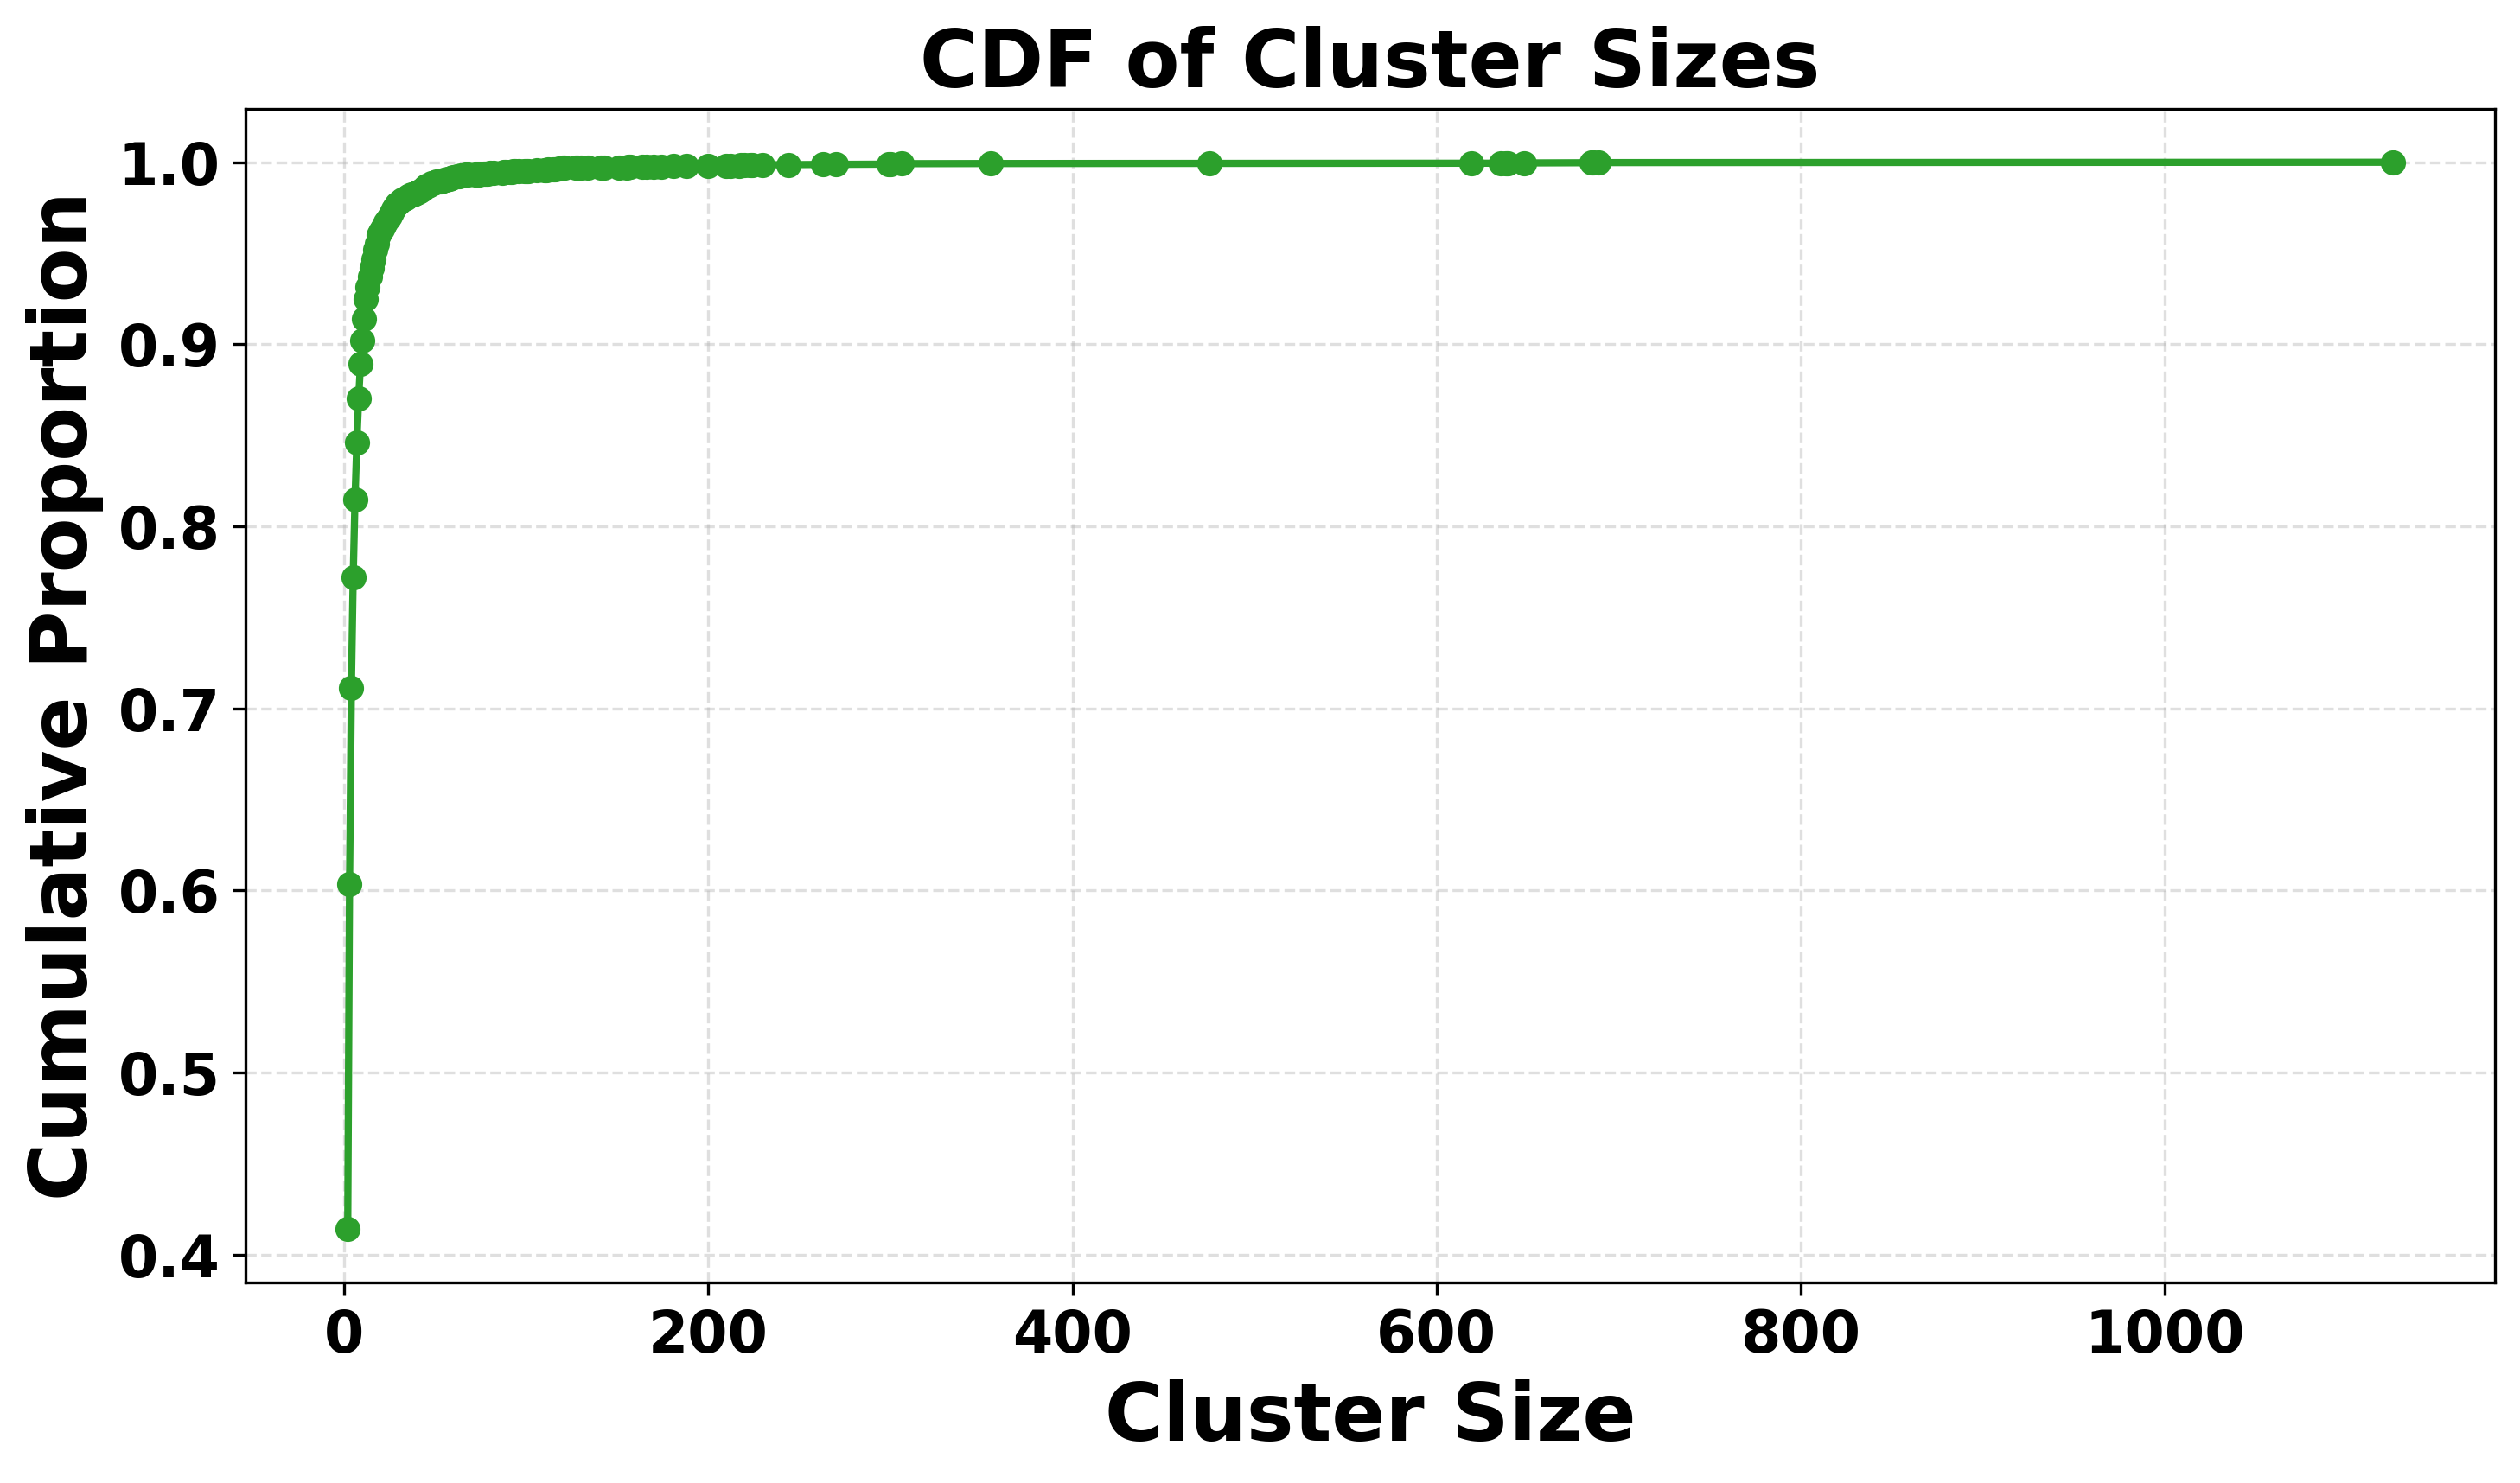

In [24]:
import numpy as np

sizes = sorted(average_cluster_counts.keys())
freqs = np.array([average_cluster_counts[size] for size in sizes])
cdf = np.cumsum(freqs) / np.sum(freqs)

plt.figure(figsize=(10,6), dpi=300)
plt.plot(sizes, cdf, marker='o', color='#2ca02c', linewidth=2)
plt.xlabel('Cluster Size', **AXIS_FONT)
plt.ylabel('Cumulative Proportion', **AXIS_FONT)
plt.title('CDF of Cluster Sizes', **TITLE_FONT)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter, defaultdict

# Font and style settings (unchanged)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.weight'] = 600
plt.rcParams['font.size'] = 16

AXIS_FONT = {'family': 'DejaVu Sans', 'weight': 600, 'size': 22}
TITLE_FONT = {'family': 'DejaVu Sans', 'weight': 600, 'size': 22}
TICK_FONT_SIZE = 22

# Paths to 5 CSVs
csv_paths = [
    '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th50.csv',
    '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th60.csv',
    '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th70.csv',
    '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th80.csv',
    '/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th90.csv',
]

# Accumulate frequencies for averaging (as in original code)
total_cluster_counts = defaultdict(int)

for csv_path in csv_paths:
    try:
        # Read CSV and process Cluster_Label
        df = pd.read_csv(csv_path)
        df['Cluster_Label'] = pd.to_numeric(df['Cluster_Label'], errors='coerce')
        labels = df['Cluster_Label'].dropna().astype(int).tolist()
        cluster_sizes = Counter([label for label in labels if label >= 0])
        size_distribution = Counter(cluster_sizes.values())

        # Calculate metrics for this CSV
        # Filter clusters with size >= 2
        valid_sizes = {size: count for size, count in size_distribution.items() if size >= 2}
        
        if valid_sizes:
            # Number of clusters: sum of counts for clusters with size >= 2
            num_clusters = sum(valid_sizes.values())
            # Maximum cluster size: largest size in valid_sizes
            max_size = max(valid_sizes.keys())
            # Average cluster size: weighted average of sizes
            avg_size = sum(size * count for size, count in valid_sizes.items()) / num_clusters
        else:
            # Handle case where no clusters have size >= 2
            num_clusters = 0
            max_size = 0
            avg_size = 0

        # Print metrics for this CSV
        print(f"\nFile: {csv_path.split('/')[-1]}")
        print(f"Number of Clusters: {num_clusters:.2f}")
        print(f"Max Size: {max_size}")
        print(f"Avg Size: {avg_size:.2f}")

        # Accumulate for averaging across files
        for size, count in size_distribution.items():
            if size >= 2:
                total_cluster_counts[size] += count

    except Exception as e:
        print(f"Error processing {csv_path}: {e}")

# Calculate and print averaged metrics (as in original code)
num_files = len(csv_paths)
average_cluster_counts = {size: total_cluster_counts[size] / num_files for size in total_cluster_counts}
num_clusters_avg = sum(average_cluster_counts.values())
max_size_avg = max(average_cluster_counts.keys()) if average_cluster_counts else 0
avg_size_avg = (
    sum(size * count for size, count in average_cluster_counts.items()) / num_clusters_avg
    if num_clusters_avg > 0
    else 0
)

# Print averaged results
print("\nAveraged Across All Files:")
print(f"Number of Clusters: {num_clusters_avg:.2f}")
print(f"Max Size: {max_size_avg}")
print(f"Avg Size: {avg_size_avg:.2f}")


File: Th50.csv
Number of Clusters: 7753.00
Max Size: 10649
Avg Size: 6.00

File: Th60.csv
Number of Clusters: 7921.00
Max Size: 8673
Avg Size: 5.59

File: Th70.csv
Number of Clusters: 8169.00
Max Size: 2447
Avg Size: 5.12

File: Th80.csv
Number of Clusters: 8135.00
Max Size: 1391
Avg Size: 4.89

File: Th90.csv
Number of Clusters: 8158.00
Max Size: 1262
Avg Size: 4.45

Averaged Across All Files:
Number of Clusters: 8027.20
Max Size: 10649
Avg Size: 5.20
